# Decision Trees Classification Assignment
## Medina County Career Center — AI/ML

**Your task:** Build a decision tree classification model from scratch using one of the datasets below.

You've seen the full process in the Iris class example. Now it's your turn!

---

### Choose Your Dataset

Pick ONE of these datasets. Each has a different classification target:

| Dataset | How to Load | What You Predict | Rows | Features | Classes | Difficulty |
|---------|-------------|------------------|------|----------|---------|------------|
| **Palmer Penguins** | `sns.load_dataset('penguins')` | Penguin species | 344 | 4 numeric | 3 | Easy |
| **Wine Recognition** | `load_wine(as_frame=True)` | Wine cultivar (vineyard) | 178 | 13 numeric | 3 | Easy-Medium |
| **Breast Cancer Wisconsin** | `load_breast_cancer(as_frame=True)` | Malignant vs Benign | 569 | 30 numeric | 2 | Medium |

See the **Dataset Guide** for full descriptions of each one.

**Note:** Wine and Breast Cancer are built into scikit-learn — no internet needed. Palmer Penguins is in seaborn.

---

### The Steps (follow this structure)

1. Import libraries (no installs needed!)
2. Load your chosen dataset
3. Explore: check shape, columns, missing values, and clean the data
4. Drop any non-numeric columns (if your dataset has them)
5. Make at least ONE scatter plot — pick two features and color by class
6. Train/test split (80/20)
7. Build and train a DecisionTreeClassifier (set max_depth=3 to start)
8. Evaluate: print accuracy and the classification report
9. Show the confusion matrix as a heatmap
10. Visualize the tree using plot_tree
11. Show feature importance as a bar chart
12. Try changing max_depth and compare accuracy

### Quick Reference — Copy and Adapt These Patterns

You don't need to switch back to the example notebook. Here are the code patterns for each step — just change the variable names and values to fit your dataset.

```python
# --- IMPORTS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- LOAD (pick the one that matches your dataset) ---

# Palmer Penguins (from seaborn):
df = sns.load_dataset('penguins')

# Wine Recognition (from sklearn — no internet needed):
from sklearn.datasets import load_wine
wine = load_wine(as_frame=True)
X = wine.data
y = wine.target
df = X.copy()
df['cultivar'] = y

# Breast Cancer Wisconsin (from sklearn — no internet needed):
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer(as_frame=True)
X = cancer.data
y = cancer.target
df = X.copy()
df['diagnosis'] = y

# --- EXPLORE + CLEAN ---
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())
df = df.dropna()

# --- DROP NON-NUMERIC COLUMNS (if needed) ---
df = df.drop(columns=['col1', 'col2'])   # drop text columns

# --- SET UP X AND y ---
X = df.drop('your_target', axis=1)
y = df['your_target']

# --- SCATTER PLOT (color by class) ---
plt.figure(figsize=(8, 6))
for className in y.unique():
    mask = y == className
    plt.scatter(X.loc[mask, 'feature1'], X.loc[mask, 'feature2'],
                label=className, alpha=0.7)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Your Title')
plt.legend()
plt.show()

# --- SPLIT ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# --- BUILD + TRAIN ---
treeModel = DecisionTreeClassifier(max_depth=3, random_state=42)
treeModel.fit(X_train, y_train)

# --- EVALUATE ---
predictions = treeModel.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy: {accuracy:.2%}')
print(classification_report(y_test, predictions))

# --- CONFUSION MATRIX ---
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# --- TREE VISUALIZATION ---
plt.figure(figsize=(16, 8))
plot_tree(treeModel, feature_names=list(X.columns),
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree')
plt.show()

# --- FEATURE IMPORTANCE ---
importanceDf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': treeModel.feature_importances_
}).sort_values('Importance', ascending=False)
plt.barh(importanceDf['Feature'], importanceDf['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()

# --- EXPERIMENT WITH DEPTH ---
for depth in [2, 3, 5, 10, None]:
    m = DecisionTreeClassifier(max_depth=depth, random_state=42)
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    print(f'max_depth={depth}: accuracy={acc:.2%}')
```

## Step 1: Install + Import Libraries

In [ ]:
# No extra installs needed!
# Palmer Penguins is in seaborn, Wine and Breast Cancer are in sklearn
print("All datasets are built-in — no pip install needed!")

In [1]:
# Import your libraries here
# Hint: you need pandas, numpy, matplotlib, seaborn, sklearn stuff
# If using UCI, also import from ucimlrepo
# Look at the class example if you need a reminder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Step 2: Load Your Dataset

**Palmer Penguins:** `sns.load_dataset('penguins')`

**Wine Recognition:** `from sklearn.datasets import load_wine` then `wine = load_wine(as_frame=True)`

**Breast Cancer:** `from sklearn.datasets import load_breast_cancer` then `cancer = load_breast_cancer(as_frame=True)`

In [2]:
# Load your chosen dataset
from sklearn.datasets import load_wine
wine = load_wine(as_frame=True)
X = wine.data
y = wine.target
df = X.copy()
df['cultivar'] = y

## Step 3: Explore the Data

Print the shape, column names, first few rows, and check for missing values. If there are missing values, drop them.

In [3]:
# Explore your data here
# - How many rows and columns?
# - What are the column names?
# - Any missing values? If so, drop them.
# - How many samples per class? (value_counts)
print(df.shape)
print(df.columns.tolist())
print(df.isnull().sum())
df = df.dropna()

(178, 14)
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'cultivar']
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
cultivar                        0
dtype: int64


## Step 4: Clean the Data

Drop any non-numeric columns (text columns like 'island', 'sex', etc.) since the tree can't use them. Then set up your X (features) and y (target) variables.

In [4]:
# Drop non-numeric columns if needed
# Set up X (features) and y (target)
X = df.drop('cultivar', axis=1)
y = df['cultivar']

## Step 5: Scatter Plot

Pick two features and make a scatter plot colored by class. This helps you see whether the classes form natural clusters or overlap a lot.

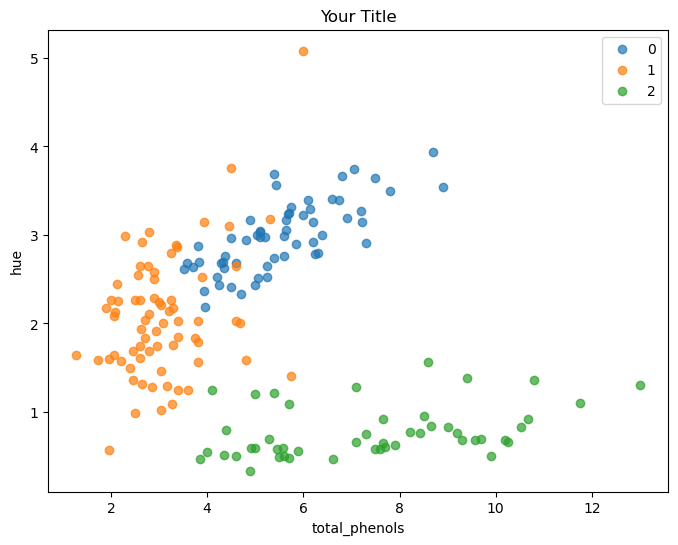

In [19]:
# Scatter plot: pick two interesting features, color by class
plt.figure(figsize=(8, 6))
for className in y.unique():
    mask = y == className
    plt.scatter(X.loc[mask, 'color_intensity'], X.loc[mask, 'flavanoids'],
                label=className, alpha=0.7)
plt.xlabel('total_phenols')
plt.ylabel('hue')
plt.title('Your Title')
plt.legend()
plt.show()

## Step 6: Train/Test Split

In [9]:
# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## Step 7: Build and Train the Decision Tree

Use `DecisionTreeClassifier(max_depth=3, random_state=42)` to start. We'll experiment with depth later.

In [10]:
# Create a DecisionTreeClassifier and fit it
treeModel = DecisionTreeClassifier(max_depth=3, random_state=42)
treeModel.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

## Step 8: Evaluate

Print the accuracy and the full classification report. The report shows precision, recall, and f1-score for each class.

In [11]:
# Make predictions and print accuracy + classification report
predictions = treeModel.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy: {accuracy:.2%}')
print(classification_report(y_test, predictions))

Accuracy: 94.44%
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        14
           1       0.88      1.00      0.93        14
           2       1.00      0.88      0.93         8

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



## Step 9: Confusion Matrix

Show the confusion matrix as a heatmap. The diagonal shows correct predictions. Off-diagonal shows mistakes — look at WHERE the model gets confused.

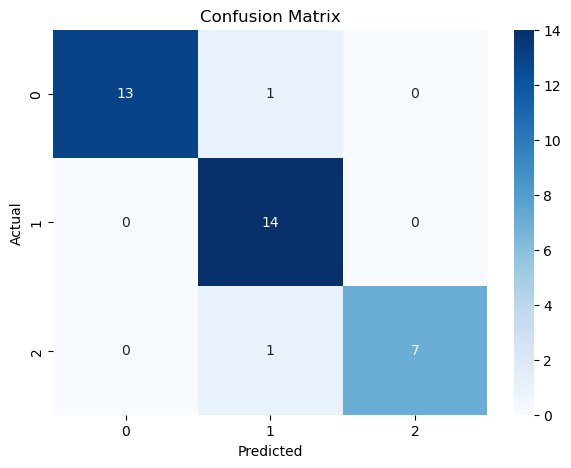

In [12]:
# Confusion matrix heatmap
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Step 10: Visualize the Tree

Use `plot_tree` to see the actual decision rules. Read through it — can you follow the yes/no questions from root to leaf?

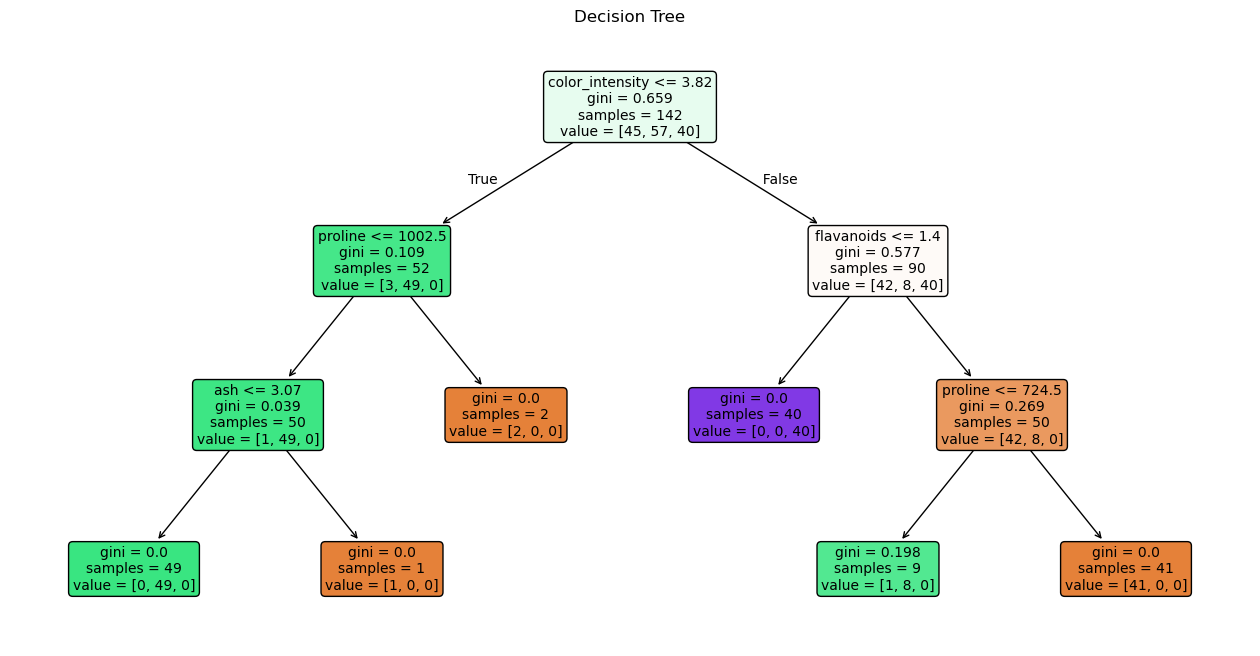

In [13]:
# Draw the decision tree
plt.figure(figsize=(16, 8))
plot_tree(treeModel, feature_names=list(X.columns),
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree')
plt.show()

## Step 11: Feature Importance

Show which features the tree uses most. Does this match what you expected from your scatter plot?

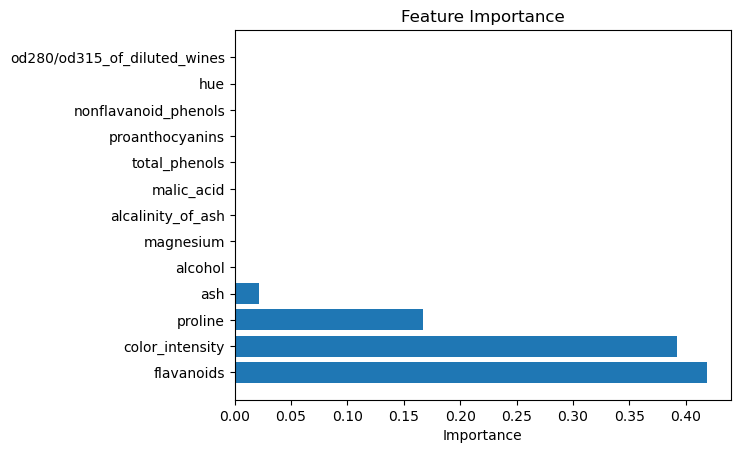

In [14]:
# Feature importance bar chart
importanceDf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': treeModel.feature_importances_
}).sort_values('Importance', ascending=False)
plt.barh(importanceDf['Feature'], importanceDf['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()

## Step 12: Experiment with max_depth

Try different values of `max_depth` (2, 3, 5, 10, and None for unlimited). Print the accuracy for each. What happens when the tree gets too deep? What happens when it's too shallow?

In [16]:
# Try different max_depth values and compare accuracy
for depth in [1, 2, 3, 5, 10, None]:
    m = DecisionTreeClassifier(max_depth=depth, random_state=42)
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    print(f'max_depth={depth}: accuracy={acc:.2%}')

max_depth=1: accuracy=66.67%
max_depth=2: accuracy=86.11%
max_depth=3: accuracy=94.44%
max_depth=5: accuracy=94.44%
max_depth=10: accuracy=94.44%
max_depth=None: accuracy=94.44%


## Reflection (answer in this cell)

1. What dataset did you choose and why?
    The wine one because I wanted to do a harder one went with the wine one.
2. What was your accuracy? Is that good or bad for your dataset?
    94.44%, good.
3. Look at your confusion matrix — where does the model make the most mistakes? Why do you think that is?
   everything is fine
4. Which feature was the most important? Does that make real-world sense?
    the flavonoids, yes because its color related
5. What happened when you changed max_depth? Was there a "sweet spot"?
     2 lowers the accuracy while 3 keeps it at the normal accuracy
6. How does building a classification model compare to the regression model you built before? What's similar? What's different?
   a regression one shows corelation